In [1]:
import torch

#### Create and inspect synthetic LiDAR points

In [126]:
points = torch.tensor([
    [10.0,  2.0,  0.5, 0.8],   # valid
    [15.0, -5.0,  1.0, 0.6],   # valid
    [-5.0,  1.0,  0.2, 0.9],   # behind ego
    [80.0,  0.0,  1.0, 0.4],   # too far
    [12.0, 30.0,  0.0, 0.7],   # outside lateral range
])
x = points[:, 0]
y = points[:, 1]
z = points[:, 2]
x.shape, y.shape, z.shape, points.shape

(torch.Size([5]), torch.Size([5]), torch.Size([5]), torch.Size([5, 4]))

In [127]:
x_range=(-10.0, 70.0)
y_range=(-30.0, 40.0)
z_range=(-4.0, 7.0)
mask = (x >= x_range[0]) & (x < x_range[1]) & (y >= y_range[0]) & (y < y_range[1]) & (z >= z_range[0]) & (z < z_range[1])
mask.shape, points.shape, mask, points[mask].shape, points[mask]

(torch.Size([5]),
 torch.Size([5, 4]),
 tensor([ True,  True,  True, False,  True]),
 torch.Size([4, 4]),
 tensor([[10.0000,  2.0000,  0.5000,  0.8000],
         [15.0000, -5.0000,  1.0000,  0.6000],
         [-5.0000,  1.0000,  0.2000,  0.9000],
         [12.0000, 30.0000,  0.0000,  0.7000]]))

### Raw synthetic LiDAR scene (top-down)

In [128]:
torch.manual_seed(42)
num_points = 1000

In [129]:
x = torch.empty(size=(num_points,)).uniform_(x_range[0], x_range[1])
y = torch.empty(size=(num_points,)).uniform_(y_range[0], y_range[1])
z = torch.empty(size=(num_points,)).uniform_(z_range[0], z_range[1])
intensity = torch.rand(size=(num_points,)) # between [0, 1)
x.shape, y.shape, z.shape, intensity.shape

(torch.Size([1000]),
 torch.Size([1000]),
 torch.Size([1000]),
 torch.Size([1000]))

In [130]:
points = torch.stack([x, y, z, intensity], dim=1)
points.shape

torch.Size([1000, 4])

In [131]:
import matplotlib.pyplot as plt

def visualize_bev(points: torch.Tensor):
    plt.figure(figsize=(10, 5))
    plt.scatter(
        points[:, 0],
        points[:, 1],
        c=points[:, 3],
        s=4,
        cmap="viridis"
    )
    plt.scatter(
        0,
        0,
        c="red",
        marker="x",
        s=100,
        label="LiDAR/ego"
    )
    plt.xlabel("x (forward)")
    plt.ylabel("y (left/right)")
    plt.title("Synthetic LiDAR - Bird's-eye View")
    plt.axis("equal")
    plt.legend()
    plt.colorbar(label="Intensity")
    plt.show()

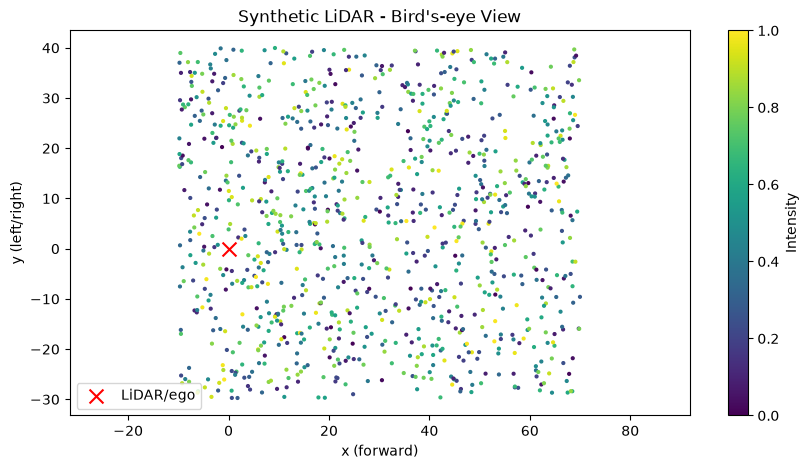

In [132]:
visualize_bev(points=points)

In [133]:
import os
import sys

project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.append(project_root)

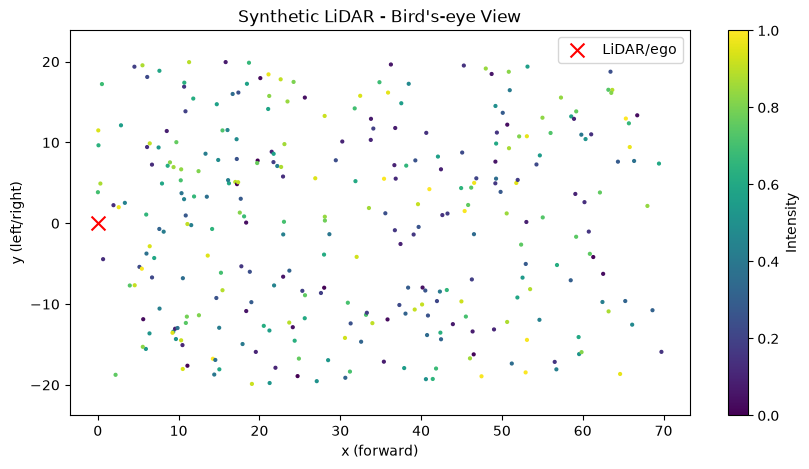

In [134]:
from src.data.lidar import filter_lidar_range
x_range1=(0.0, 70.0)
y_range1=(-20.0, 20.0)
z_range1=(-3.0, 3.0)
filtered_points = filter_lidar_range(points=points,
                                     x_range=x_range1,
                                     y_range=y_range1,
                                     z_range=z_range1)
visualize_bev(points=filtered_points)

In [135]:
points.shape, filtered_points.shape

(torch.Size([1000, 4]), torch.Size([308, 4]))

#### Plot ROI

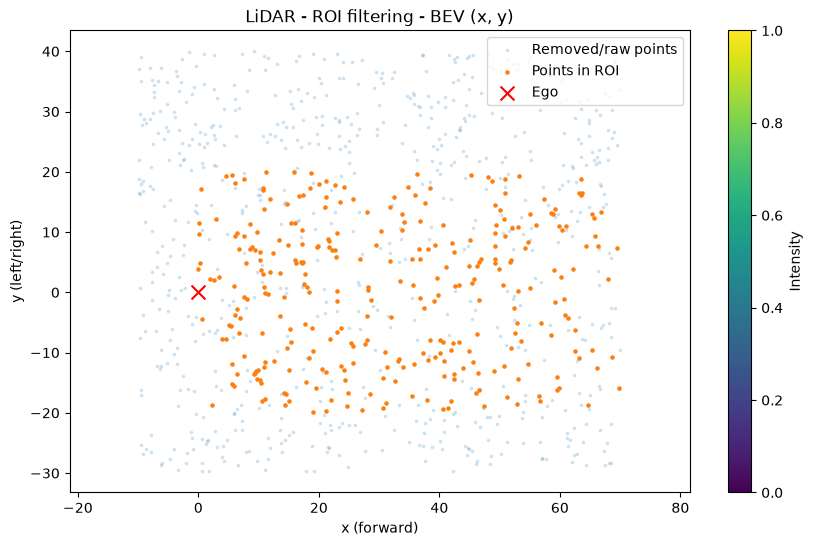

In [136]:
plt.figure(figsize=(10, 6))

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=3,
    alpha=0.15,
    label="Removed/raw points"
)
plt.scatter(
    filtered_points[:, 0],
    filtered_points[:, 1],
    s=5,
    label="Points in ROI"
)
plt.scatter(
    0,
    0,
    c="red",
    s=100,
    marker="x",
    label="Ego"
)
plt.xlabel("x (forward)")
plt.ylabel("y (left/right)")
plt.title("LiDAR - ROI filtering - BEV (x, y)")
plt.axis("equal")
plt.legend()
plt.colorbar(label="Intensity")
plt.show()

### Visualize x-z (height) from the side-view

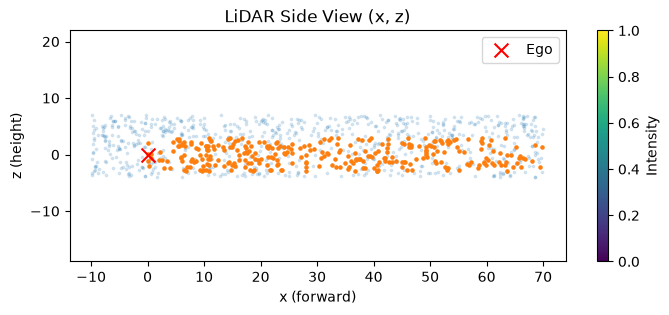

In [137]:
plt.figure(figsize=(8, 3))

plt.scatter(
    points[:, 0],
    points[:, 2], # plot height on y axis
    # c=points[:, 3],
    s=3,
    alpha=0.15
)
plt.scatter(
    filtered_points[:, 0],
    filtered_points[:, 2], # plot height on y axis
    # c=filtered_points[:, 3],
    s=5
)
plt.scatter(
    0,
    0,
    c="red",
    s=100,
    marker="x",
    label="Ego"
)
plt.xlabel("x (forward)")
plt.ylabel("z (height)")
plt.title("LiDAR Side View (x, z)")
plt.axis("equal")
plt.legend()
plt.colorbar(label="Intensity")
plt.show()